In [46]:
# Import Packages 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import zipfile
import statsmodels.formula.api as smf
import statsmodels.api as sm

## Data Merge

In [10]:
data_2010 = pd.read_csv("../Data/output/data-2010.csv", low_memory=False)
data_2011 = pd.read_csv("../Data/output/data-2011.csv", low_memory=False)
data_2012 = pd.read_csv("../Data/output/data-2012.csv", low_memory=False)
data_2013 = pd.read_csv("../Data/output/data-2013.csv", low_memory=False)
data_2014 = pd.read_csv("../Data/output/data-2014.csv", low_memory=False)
data_2015 = pd.read_csv("../Data/output/data-2015.csv", low_memory=False)

In [11]:
data_2010["year"] = 2010
data_2011["year"] = 2011
data_2012["year"] = 2012
data_2013["year"] = 2013
data_2014["year"] = 2014
data_2015["year"] = 2015

In [12]:
data = pd.concat([data_2010, data_2011, data_2012, data_2013, data_2014, data_2015], ignore_index=True)

## Question 1

In [13]:
WORK_DIR = Path.cwd().resolve().parent
STAR_DIR = WORK_DIR / "ma-data/ma/star-ratings"
EXTRACTED = STAR_DIR / "Extracted Star Ratings"

def parse_number_like_readr(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return np.nan
    s = str(x).strip()
    if s == "":
        return np.nan
    s = s.replace(",", "")
    m = re.search(r"-?\d+(?:\.\d+)?", s)
    return float(m.group(0)) if m else np.nan

def ensure_unzipped(zip_path: Path, extract_to: Path) -> Path:
    extract_to.mkdir(parents=True, exist_ok=True)
    if any(extract_to.iterdir()):
        return extract_to
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    return extract_to

def find_summary_csv_in_folder(folder: Path) -> Path:
    csvs = list(folder.rglob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    summaries = [p for p in csvs if "summary" in p.name.lower()]
    if not summaries:
        raise FileNotFoundError(f"No *summary*.csv found in {folder}. Example: {[p.name for p in csvs[:10]]}")
    return sorted(summaries, key=lambda p: p.name.lower())[0]

def read_partc_summary_headerflex(path: Path, year: int) -> pd.DataFrame:
    """
    Flexible header-format reader:
    - skips 1 row (title), uses row 2 as header
    - pulls Contract Number + best available overall rating column
    """
    tmp = pd.read_csv(path, skiprows=1, encoding="latin1")

    # standard contract column
    contract_col = "Contract Number"
    if contract_col not in tmp.columns:
        raise RuntimeError(f"{path.name}: couldn't find '{contract_col}'. First cols: {list(tmp.columns)[:10]}")

 
    cand_cols = [
    f"{year} Overall Rating",
    f"{year} Overall",                 
    f"{year} Part C Summary Rating",
    f"{year} Part C Summary",          
    "Overall Rating",
    "Overall",                        
    "Part C Summary Rating",
    "Part C Summary",                 
    ]

    rating_col = next((c for c in cand_cols if c in tmp.columns), None)
    if rating_col is None:
        raise RuntimeError(
            f"{path.name}: couldn't find rating column. "
            f"Tried {cand_cols}. Columns include: {list(tmp.columns)[:15]}"
        )

    out = tmp[[contract_col, rating_col]].rename(columns={contract_col: "contractid", rating_col: "star_partc"}).copy()
    out["star_partc"] = out["star_partc"].map(parse_number_like_readr).astype("float64")
    return out

def read_partc_summary_old5col(path: Path) -> pd.DataFrame:
    """
    Old 5-column format reader (mostly for 2010 in your setup).
    """
    for sk in [2, 3, 4, 0, 1]:
        try:
            tmp = pd.read_csv(
                path,
                skiprows=sk,
                names=["contractid", "org_type", "contract_name", "org_marketing", "partc_score"],
                header=None,
                na_values=["", "NA", "*"],
                keep_default_na=True,
                encoding="latin1",
            )
            share_valid = tmp["contractid"].astype(str).str.match(r"^[A-Z]\d{4}$", na=False).mean()
            if share_valid < 0.5:
                continue

            tmp["new_contract"] = (tmp["partc_score"] == "Plan too new to be measured").astype("int64")
            tmp["partc_score"] = tmp.apply(
                lambda r: np.nan if r["new_contract"] == 1 else parse_number_like_readr(r["partc_score"]),
                axis=1
            ).astype("float64")

            return tmp.loc[:, ["contractid", "partc_score"]].rename(columns={"partc_score": "star_partc"})
        except Exception:
            continue
    raise RuntimeError(f"Could not parse old 5-col summary file: {path}")

def load_partc_stars(folder: Path, year: int) -> pd.DataFrame:
    """
    Loads contract-level star rating from folder for given year.
    Tries header-flex first (works for 2011, 2012, 2013, 2014, often 2015),
    falls back to old5col (works for 2010).
    """
    summary_path = find_summary_csv_in_folder(folder)


    try:
        out = read_partc_summary_headerflex(summary_path, year)
        return out.assign(year=year)
    except Exception:
        # fallback
        out = read_partc_summary_old5col(summary_path)
        return out.assign(year=year)


stars_2010 = load_partc_stars(EXTRACTED / "2010", 2010)
stars_2011 = load_partc_stars(EXTRACTED / "2011", 2011)
stars_2012 = load_partc_stars(EXTRACTED / "Part C 2012 Fall", 2012)
stars_2013 = load_partc_stars(EXTRACTED / "Part C 2013 Spring", 2013)
stars_2014 = load_partc_stars(EXTRACTED / "Part C 2014 Spring", 2014)
zip_2015 = STAR_DIR / "2015-Part-C-and-D-Medicare-Star-Ratings-Data.zip"


extract_2015 = Path.cwd().resolve() / "2015_extracted"
ensure_unzipped(zip_2015, extract_2015)

stars_2015 = load_partc_stars(extract_2015, 2015)

In [14]:
df = data.copy()
df = df[df["year"].between(2010, 2015)].copy()

df["plan_uid"] = df["contractid"].astype(str) + "-" + df["planid"].astype(str)
df["avg_enrollment"] = pd.to_numeric(df["avg_enrollment"], errors="coerce")

# market share within county-year
df["market_total_enrollment"] = df.groupby(["contractid", "year","planid"])["avg_enrollment"].transform("sum")
df["market_share"] = np.where(df["market_total_enrollment"] > 0,
                              df["avg_enrollment"] / df["market_total_enrollment"],
                              np.nan)

stars_all = pd.concat(
    [stars_2010, stars_2011, stars_2012, stars_2013, stars_2014, stars_2015],
    ignore_index=True
)

df = df.merge(stars_all, on=["contractid", "year"], how="left")

summary_table = (
    df.groupby("year")
      .agg(
          mean_star_rating=("star_partc", "mean"),
          mean_enrollment=("avg_enrollment", "mean"),
          mean_market_share=("market_share", "mean"),
          num_plans=("plan_uid", "nunique"),
      )
      .reset_index()
      .sort_values("year")
)

summary_table = summary_table.round({"mean_star_rating": 2, "mean_enrollment": 0, "mean_market_share": 4})
summary_table.columns = ["Year", "Mean Star Rating", "Mean Enrollment", "Mean Market Share", "Number of Plans"]

summary_table

,Year,Mean Star Rating,Mean Enrollment,Mean Market Share,Number of Plans
0,2010,2.97,257.0,0.0761,2527
1,2011,3.17,344.0,0.0816,2158
2,2012,3.27,378.0,0.0820,2154
3,2013,3.53,396.0,0.0827,2272
4,2014,3.75,437.0,0.0850,2256
5,2015,3.98,470.0,0.0836,2241


## Question 2

In [15]:
df_nostars = df[df["star_partc"].isna()].copy()

summary_table_q2 = (
    df_nostars.groupby("year")
      .agg(
          mean_enrollment=("avg_enrollment", "mean"),
          mean_market_share=("market_share", "mean"),
          num_plans=("plan_uid", "nunique"),
      )
      .reset_index()
      .sort_values("year")
)

summary_table_q2 = summary_table_q2.round({
    "mean_enrollment": 0,
    "mean_market_share": 4
})

summary_table_q2.columns = [
    "Year",
    "Mean Enrollment",
    "Mean Market Share",
    "Number of Plans (No Rating)"
]

summary_table_q2

,Year,Mean Enrollment,Mean Market Share,Number of Plans (No Rating)
0,2010,107.0,0.0719,964
1,2011,173.0,0.0972,755
2,2012,173.0,0.1115,494
3,2013,213.0,0.1983,409
4,2014,255.0,0.1983,489
5,2015,329.0,0.1724,553


## Question 3

In [16]:
df_stars = df[df["year"].isin([2010, 2012, 2015])].copy()

df_stars = df_stars[df_stars["star_partc"].notna()].copy()

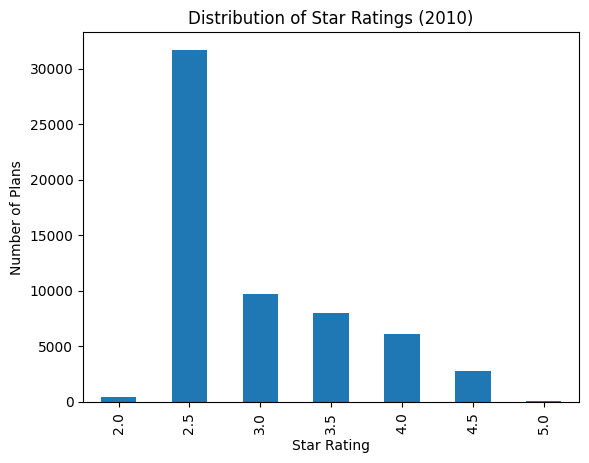

In [17]:
# 2010
dist_2010 = (
    df_stars[df_stars["year"] == 2010]["star_partc"]
    .value_counts()
    .sort_index()
)

plt.figure()
dist_2010.plot(kind="bar")
plt.title("Distribution of Star Ratings (2010)")
plt.xlabel("Star Rating")
plt.ylabel("Number of Plans")
plt.show()

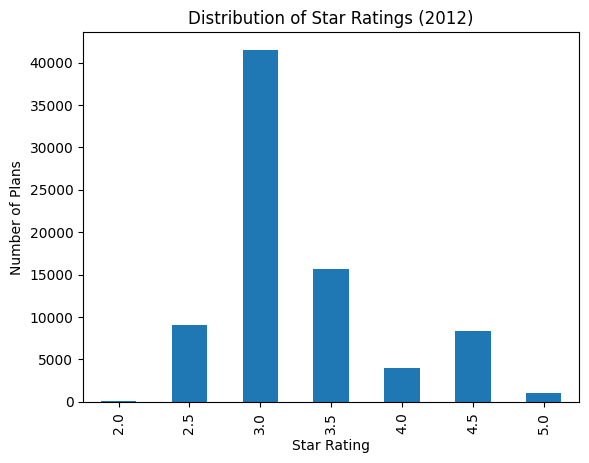

In [18]:
#2012
dist_2012 = (
    df_stars[df_stars["year"] == 2012]["star_partc"]
    .value_counts()
    .sort_index()
)

plt.figure()
dist_2012.plot(kind="bar")
plt.title("Distribution of Star Ratings (2012)")
plt.xlabel("Star Rating")
plt.ylabel("Number of Plans")
plt.show()

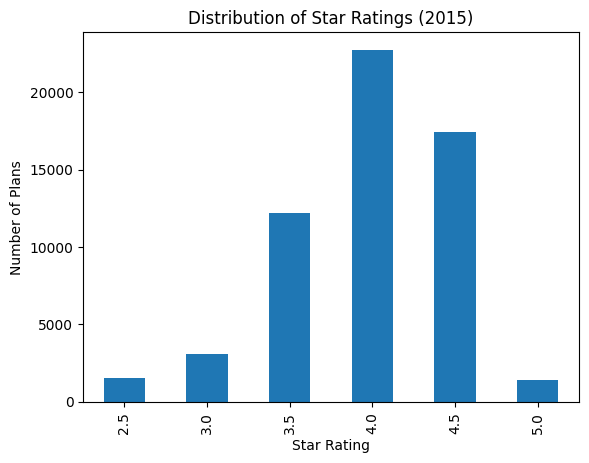

In [19]:
#2015
dist_2015 = (
    df_stars[df_stars["year"] == 2015]["star_partc"]
    .value_counts()
    .sort_index()
)

plt.figure()
dist_2015.plot(kind="bar")
plt.title("Distribution of Star Ratings (2015)")
plt.xlabel("Star Rating")
plt.ylabel("Number of Plans")
plt.show()

Interpretation: The distribution of star ratings from 2010 to 2015 seems to shift upward over time. In 2010, most plans are concentrated between 2.5 and 3, however by 2012 the distribution begins to shift upwards, with most plans concentrating around 3.5 and 4 stars. By 2015, most plans concentrate around 4 to 4.5 stars, and lower rated plans became much less common. 

## Question 4

In [20]:
df_reg = df.copy()

df_reg = df_reg[df_reg["star_partc"].notna()].copy()

# Create rating categories
def rating_group(x):
    if x <= 2.5:
        return "2.5_or_below"
    elif x == 3:
        return "3"
    elif x == 3.5:
        return "3.5"
    elif x == 4:
        return "4"
    else:
        return "4.5_or_above"

df_reg["rating_group"] = df_reg["star_partc"].apply(rating_group)

In [21]:
results = {}

for yr in range(2010, 2016):
    temp = df_reg[df_reg["year"] == yr].copy()

    model = smf.ols(
        "market_share ~ C(rating_group, Treatment(reference='2.5_or_below'))",
        data=temp
    ).fit()

    results[yr] = model

In [22]:
coef_table = pd.DataFrame()

for yr in results:
    coefs = results[yr].params
    coefs = coefs.drop("Intercept")

    coef_table[yr] = coefs

coef_table

,2010,2011,2012,2013,2014,2015
"C(rating_group, Treatment(reference='2.5_or_below'))[T.3]",0.086618,0.040638,-0.013227,0.022047,0.015952,0.033983
"C(rating_group, Treatment(reference='2.5_or_below'))[T.3.5]",0.058298,0.090955,0.040575,0.006867,0.020143,0.037276
"C(rating_group, Treatment(reference='2.5_or_below'))[T.4]",0.056116,0.059503,0.037672,0.045647,0.044040,0.012210
"C(rating_group, Treatment(reference='2.5_or_below'))[T.4.5_or_above]",0.084303,0.051758,0.011593,0.021693,0.041649,0.021536


In [23]:
coef_table.index = [
    "3 stars",
    "3.5 stars",
    "4 stars",
    "4.5+ stars"
]

coef_table.round(4)

,2010,2011,2012,2013,2014,2015
3 stars,0.0866,0.0406,-0.0132,0.0220,0.0160,0.0340
3.5 stars,0.0583,0.0910,0.0406,0.0069,0.0201,0.0373
4 stars,0.0561,0.0595,0.0377,0.0456,0.0440,0.0122
4.5+ stars,0.0843,0.0518,0.0116,0.0217,0.0416,0.0215


## Question 5

In [24]:
df_2010 = df[df["year"] == 2010].copy()
df_2010 = df_2010[df_2010["star_partc"].notna()].copy()

df_2010["plan_uid"] = df_2010["contractid"].astype(str) + "-" + df_2010["planid"].astype(str)
df_2010 = df_2010.drop_duplicates("plan_uid")

In [25]:
df_2010["cutoff"] = df_2010["star_partc"] - 0.25
df_2010["running"] = df_2010["star_partc"] - df_2010["cutoff"]

In [26]:
targets = [3.0, 3.5, 4.0, 4.5, 5.0]

rounded_up_table_2010 = (
    df_2010[df_2010["star_partc"].isin(targets)]
    .groupby("star_partc")
    .size()
    .reindex(targets, fill_value=0)
    .reset_index()
)

rounded_up_table_2010.columns = [
    "Star Rating",
    "Number of Plans Rounded Up Into Rating (2010)"
]

rounded_up_table_2010

,Star Rating,Number of Plans Rounded Up Into Rating (2010)
0,3.0,474
1,3.5,320
2,4.0,239
3,4.5,166
4,5.0,8


## Question 6

In [64]:
rd_3 = df_2010[df_2010["star_partc"].isin([2.5, 3])]

effect_3 = (
    rd_3[rd_3["star_partc"] == 2.5]["market_share"].mean()
    - rd_3[rd_3["star_partc"] == 3]["market_share"].mean()
)

In [65]:
rd_35 = df_2010[df_2010["star_partc"].isin([3, 3.5])]

effect_35 = (
    rd_35[rd_35["star_partc"] == 3.5]["market_share"].mean()
    - rd_35[rd_35["star_partc"] == 3]["market_share"].mean()
)

In [66]:
rd_results = pd.DataFrame({
    "Cutoff": ["3-star vs 2.5-star", "3.5-star vs 3-star"],
    "RD Estimate (Effect on Enrollment)": [effect_3, effect_35]
})

rd_results

,Cutoff,RD Estimate (Effect on Enrollment)
0,3-star vs 2.5-star,0.039641
1,3.5-star vs 3-star,-0.047534


## Question 7

In [56]:
bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]

results = []

for bw in bandwidths:
    
    # 3-star cutoff
    rd_3 = df_2010[df_2010["star_partc"].isin([2.5, 3])]
    
    effect_3 = (
        rd_3[rd_3["star_partc"] == 3]["market_share"].mean()
        - rd_3[rd_3["star_partc"] == 2.5]["market_share"].mean()
    )
    
    # standard error
    se_3 = np.sqrt(
        rd_3[rd_3["star_partc"] == 3]["market_share"].var()/len(rd_3[rd_3["star_partc"] == 3]) +
        rd_3[rd_3["star_partc"] == 2.5]["market_share"].var()/len(rd_3[rd_3["star_partc"] == 2.5])
    )

    # 3.5-star cutoff
    rd_35 = df_2010[df_2010["star_partc"].isin([3, 3.5])]
    
    effect_35 = (
        rd_35[rd_35["star_partc"] == 3.5]["market_share"].mean()
        - rd_35[rd_35["star_partc"] == 3]["market_share"].mean()
    )

    se_35 = np.sqrt(
        rd_35[rd_35["star_partc"] == 3.5]["market_share"].var()/len(rd_35[rd_35["star_partc"] == 3.5]) +
        rd_35[rd_35["star_partc"] == 3]["market_share"].var()/len(rd_35[rd_35["star_partc"] == 3])
    )
    
    results.append([bw, effect_3, se_3, effect_35, se_35])

rd_sensitivity = pd.DataFrame(results, columns=[
    "Bandwidth",
    "Effect_3",
    "SE_3",
    "Effect_35",
    "SE_35"
])

rd_sensitivity

,Bandwidth,Effect_3,SE_3,Effect_35,SE_35
0,0.10,-0.039641,0.028036,-0.047534,0.025513
1,0.12,-0.039641,0.028036,-0.047534,0.025513
2,0.13,-0.039641,0.028036,-0.047534,0.025513
3,0.14,-0.039641,0.028036,-0.047534,0.025513
4,0.15,-0.039641,0.028036,-0.047534,0.025513


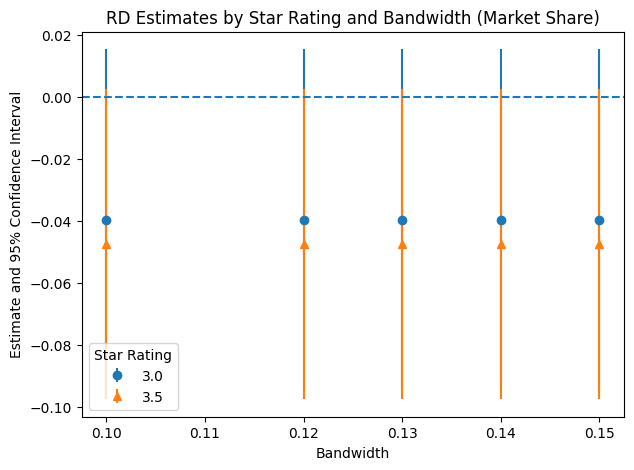

In [57]:
plt.figure(figsize=(7,5))

# 3 star
plt.errorbar(
    rd_sensitivity["Bandwidth"],
    rd_sensitivity["Effect_3"],
    yerr=1.96*rd_sensitivity["SE_3"],
    fmt="o",
    label="3.0"
)

# 3.5 star
plt.errorbar(
    rd_sensitivity["Bandwidth"],
    rd_sensitivity["Effect_35"],
    yerr=1.96*rd_sensitivity["SE_35"],
    fmt="^",
    label="3.5"
)

plt.axhline(0, linestyle="--")
plt.xlabel("Bandwidth")
plt.ylabel("Estimate and 95% Confidence Interval")
plt.title("RD Estimates by Star Rating and Bandwidth (Market Share)")
plt.legend(title="Star Rating")

plt.show()

Interpretation: The RD estimates are not sensitive to the choice of bandwith within the specified range as the estimated treatment effects remain constant. 

## Question 8

In [32]:
cutoff_3 = 2.75
df_2010["running_3"] = df_2010["star_partc"] - cutoff_3

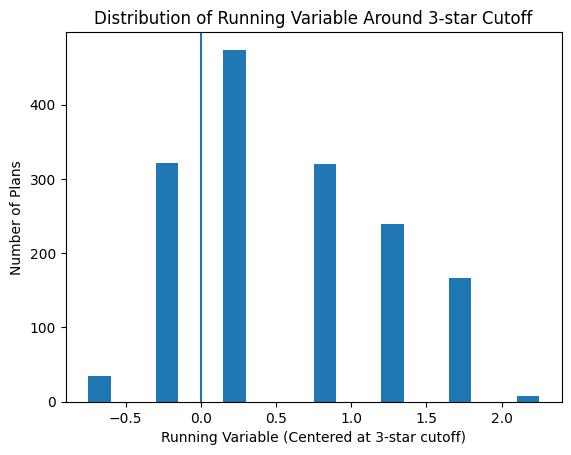

In [33]:
plt.figure()
plt.hist(df_2010["running_3"], bins=20)
plt.axvline(0)
plt.xlabel("Running Variable (Centered at 3-star cutoff)")
plt.ylabel("Number of Plans")
plt.title("Distribution of Running Variable Around 3-star Cutoff")
plt.show()

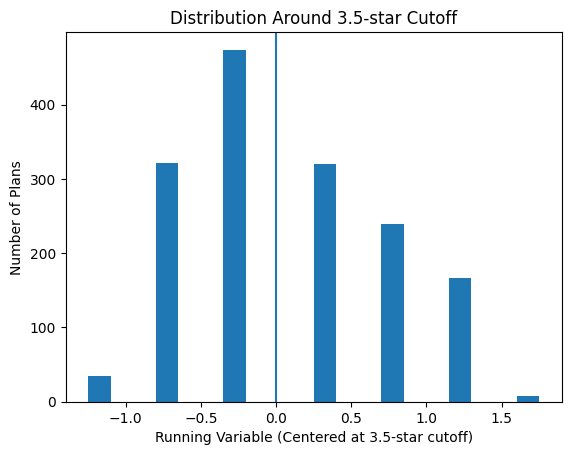

In [34]:
cutoff_35 = 3.25
df_2010["running_35"] = df_2010["star_partc"] - cutoff_35

plt.figure()
plt.hist(df_2010["running_35"], bins=20)
plt.axvline(0)
plt.xlabel("Running Variable (Centered at 3.5-star cutoff)")
plt.ylabel("Number of Plans")
plt.title("Distribution Around 3.5-star Cutoff")
plt.show()

Interpretation: The graphs do not show any clear jump in the number of plans just above the cutoff compared to just below it, suggesting there is no obvious evidence that contracts manipulated their ratings around the threshold.

## Question 9

In [35]:
df_2010 = df[df["year"] == 2010].copy()
df_2010 = df_2010[df_2010["star_partc"].notna()].copy()

df_2010["plan_uid"] = df_2010["contractid"].astype(str) + "-" + df_2010["planid"].astype(str)
df_2010 = df_2010.drop_duplicates("plan_uid")

In [36]:
df_2010["is_hmo"] = df_2010["plan_type"].astype(str).str.contains("HMO", case=False, na=False).astype(int)

df_2010["has_partd"] = (
    df_2010["partd"].astype(str).str.strip().str.lower()
      .map({"yes": 1, "no": 0})
)

In [37]:
df_2010[["plan_type","is_hmo","partd","has_partd"]].head(10)
df_2010["has_partd"].value_counts(dropna=False)

has_partd
1    1237
0     326
Name: count, dtype: int64

In [38]:
rd_3 = df_2010[df_2010["star_partc"].isin([2.5, 3])].copy()

balance_3 = (
    rd_3.groupby("star_partc")
        .agg(
            n_plans=("plan_uid", "size"),
            HMO_rate=("is_hmo", "mean"),
            PartD_rate=("has_partd", "mean"),
        )
        .reset_index()
)

balance_3

,star_partc,n_plans,HMO_rate,PartD_rate
0,2.5,321,0.626168,0.838006
1,3.0,474,0.808017,0.831224


In [39]:
rd_35 = df_2010[df_2010["star_partc"].isin([3, 3.5])].copy()

balance_35 = (
    rd_35.groupby("star_partc")
         .agg(
            n_plans=("plan_uid", "size"),
            HMO_rate=("is_hmo", "mean"),
            PartD_rate=("has_partd", "mean"),
         )
         .reset_index()
)

balance_35

,star_partc,n_plans,HMO_rate,PartD_rate
0,3.0,474,0.808017,0.831224
1,3.5,320,0.568750,0.828125


In [40]:
def diff_table(balance_df, below, above):
    b = balance_df[balance_df["star_partc"] == below].iloc[0]
    a = balance_df[balance_df["star_partc"] == above].iloc[0]
    return pd.DataFrame({
        "Cutoff": [f"{above} vs {below}"],
        "Δ HMO rate": [a["HMO_rate"] - b["HMO_rate"]],
        "Δ Part D rate": [a["PartD_rate"] - b["PartD_rate"]],
        "n_below": [b["n_plans"]],
        "n_above": [a["n_plans"]],
    })

diff_3  = diff_table(balance_3, 2.5, 3.0)
diff_35 = diff_table(balance_35, 3.0, 3.5)

pd.concat([diff_3, diff_35], ignore_index=True)

,Cutoff,Δ HMO rate,Δ Part D rate,n_below,n_above
0,3.0 vs 2.5,0.181849,-0.006783,321.0,474.0
1,3.5 vs 3.0,-0.239267,-0.003099,474.0,320.0


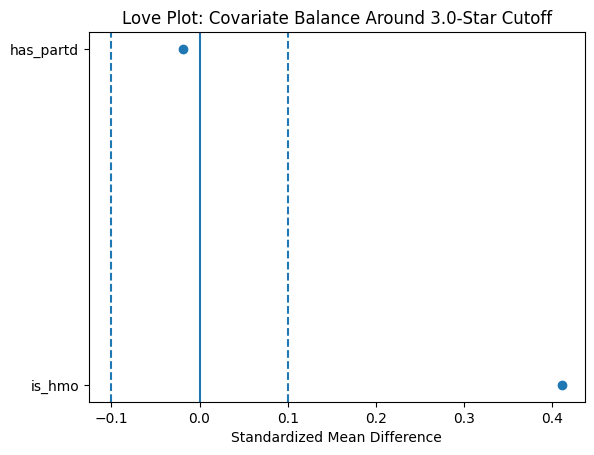

In [42]:
def smd(x_above, x_below):
    m1, m0 = x_above.mean(), x_below.mean()
    s1, s0 = x_above.std(ddof=1), x_below.std(ddof=1)
    pooled = np.sqrt((s1**2 + s0**2) / 2)
    return (m1 - m0) / pooled

rd_3 = df_2010[df_2010["star_partc"].isin([2.5, 3])].copy()

covars = ["is_hmo", "has_partd"]

smd_vals = []

for c in covars:
    above = rd_3[rd_3["star_partc"] == 3][c]
    below = rd_3[rd_3["star_partc"] == 2.5][c]
    smd_vals.append(smd(above, below))

plt.figure()

plt.scatter(smd_vals, covars)

plt.axvline(0)
plt.axvline(0.1, linestyle="--")
plt.axvline(-0.1, linestyle="--")

plt.xlabel("Standardized Mean Difference")
plt.title("Love Plot: Covariate Balance Around 3.0-Star Cutoff")
plt.show()

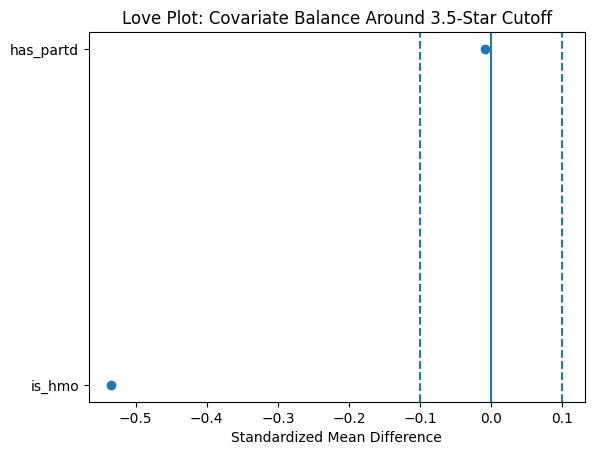

In [43]:
rd_35 = df_2010[df_2010["star_partc"].isin([3, 3.5])].copy()

smd_vals = []

for c in covars:
    above = rd_35[rd_35["star_partc"] == 3.5][c]
    below = rd_35[rd_35["star_partc"] == 3][c]
    smd_vals.append(smd(above, below))

plt.figure()

plt.scatter(smd_vals, covars)

plt.axvline(0)
plt.axvline(0.1, linestyle="--")
plt.axvline(-0.1, linestyle="--")

plt.xlabel("Standardized Mean Difference")
plt.title("Love Plot: Covariate Balance Around 3.5-Star Cutoff")
plt.show()

## Question 10

The RD analysis for 2010 provides little evidence that marginal increases in star ratings increased enrollment. The estimates are stable across bandwidths and there is no clear sign of manipulation at the thresholds, although some imbalance in HMO status suggests caution in interpreting the results as fully causal.